In [3]:
import yfinance as yf
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import time

In [18]:
STOCKS = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS"]


# optional run only first time if you dont have dataset and want to generate it
def fetch_stock_data(symbol: str, period: str = "5y", interval: str = "1d") -> pd.DataFrame:
    try:
        print(f"📥 Fetching {symbol}...")
        df = yf.download(symbol, period=period, interval=interval, auto_adjust=True)

        if df.empty:
            print(f"⚠️ No data for {symbol}")
            return None

        # Fix MultiIndex columns (yfinance >= 0.2.x)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df.reset_index(inplace=True)

        # Rename Datetime to Date (for intraday intervals)
        if "Datetime" in df.columns:
            df.rename(columns={"Datetime": "Date"}, inplace=True)

        df["Symbol"] = symbol

        print(f"✅ {symbol} → {len(df)} rows fetched")
        return df

    except Exception as e:
        print(f"❌ Error fetching {symbol}: {e}")
        return None


def fetch_all_stocks() -> pd.DataFrame:
    all_data = []

    for stock in STOCKS:
        df = fetch_stock_data(stock)
        if df is not None:
            all_data.append(df)
        time.sleep(1)  # Avoid rate limiting

    if not all_data:
        print("❌ No data fetched")
        return None

    final_df = pd.concat(all_data, ignore_index=True)
    final_df.sort_values(by=["Symbol", "Date"], inplace=True)
    final_df.reset_index(drop=True, inplace=True)

    return final_df


def save_to_csv(df,name) -> None:
    if df is None:
        print("❌ Nothing to save")
        return

    # Drop duplicate rows if any
    df.drop_duplicates(subset=["Symbol", "Date"], inplace=True)

    df.to_csv(name, index=False)
    print(f"\n✅ CSV saved successfully with {len(df)} total rows")
    print(df.groupby("Symbol").size().rename("rows"))  # Show row count per stock


save_to_csv(fetch_all_stocks(),"stocks_data.csv")

📥 Fetching RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed


✅ RELIANCE.NS → 1237 rows fetched
📥 Fetching TCS.NS...


[*********************100%***********************]  1 of 1 completed


✅ TCS.NS → 1237 rows fetched
📥 Fetching INFY.NS...


...

✅ INFY.NS → 1237 rows fetched
📥 Fetching HDFCBANK.NS...


[*********************100%***********************]  1 of 1 completed


✅ HDFCBANK.NS → 1237 rows fetched
📥 Fetching ICICIBANK.NS...


[*********************100%***********************]  1 of 1 completed


✅ ICICIBANK.NS → 1237 rows fetched

✅ CSV saved successfully with 6185 total rows
Symbol
HDFCBANK.NS     1237
ICICIBANK.NS    1237
INFY.NS         1237
RELIANCE.NS     1237
TCS.NS          1237
Name: rows, dtype: int64


In [19]:
# Style
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")

# Load
df = pd.read_csv("output.csv", parse_dates=["Date"])
df.sort_values(["Symbol", "Date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(6185, 7)
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Symbol            object
dtype: object
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Symbol    0
dtype: int64


,Date,Close,High,Low,Open,Volume,Symbol
0,2021-04-27,681.350830,682.913693,665.296248,666.456515,20592906,HDFCBANK.NS
1,2021-04-28,699.394470,700.436340,677.704126,680.190462,24103940,HDFCBANK.NS
2,2021-04-29,697.358032,712.110304,691.911773,703.846162,24078552,HDFCBANK.NS
3,2021-04-30,668.848083,688.501978,666.574839,684.334382,35232902,HDFCBANK.NS
4,2021-05-03,669.866211,673.394475,652.272471,659.707776,22473700,HDFCBANK.NS


In [7]:
print("=" * 50)
print("Stocks in dataset:", df["Symbol"].unique())
print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Total rows:", len(df))
print("=" * 50)

df.groupby("Symbol")[["Close", "Volume"]].describe().round(2)

Stocks in dataset: ['HDFCBANK.NS' 'ICICIBANK.NS' 'INFY.NS' 'RELIANCE.NS' 'TCS.NS']
Date range: 2021-04-27 00:00:00 → 2026-04-27 00:00:00
Total rows: 6185


Close                                                       \
               count     mean     std      min      25%      50%      75%   
Symbol                                                                      
HDFCBANK.NS   1237.0   796.34   99.80   616.52   718.76   782.30   845.62   
ICICIBANK.NS  1237.0  1018.36  264.10   572.14   794.74   951.88  1262.66   
INFY.NS       1237.0  1478.32  180.08  1122.01  1349.93  1458.18  1580.14   
RELIANCE.NS   1237.0  1251.22  166.26   867.48  1128.36  1222.57  1407.18   
TCS.NS        1237.0  3256.19  405.76  2356.00  2971.19  3166.91  3460.31   

                       Volume                                             \
                  max   count         mean          std  min         25%   
Symbol                                                                     
HDFCBANK.NS   1012.90  1237.0  26240463.29  25091726.96  0.0  13150406.0   
ICICIBANK.NS  1477.20  1237.0  13997801.76   7513715.63  0.0   9222544.0   
INFY.NS       1942.22  1237.0   7133225.82   4478531.34  0.0   4596579.0   
RELIANCE.NS   1592.30  1237.0  13449329.08   7351451.53  0.0   8910166.0   
TCS.NS        4311.59  1237.0   2447840.13   1370946.55  0.0   1618931.0   

                                                   
                     50%         75%          max  
Symbol                                             
HDFCBANK.NS   20482940.0  32722086.0  445342100.0  
ICICIBANK.NS  12267898.0  16659001.0   96124084.0  
INFY.NS        6119965.0   8180782.0   53171705.0  
RELIANCE.NS   11785109.0  16027522.0   91461975.0  
TCS.NS         2070859.0   2890357.0   13509164.0

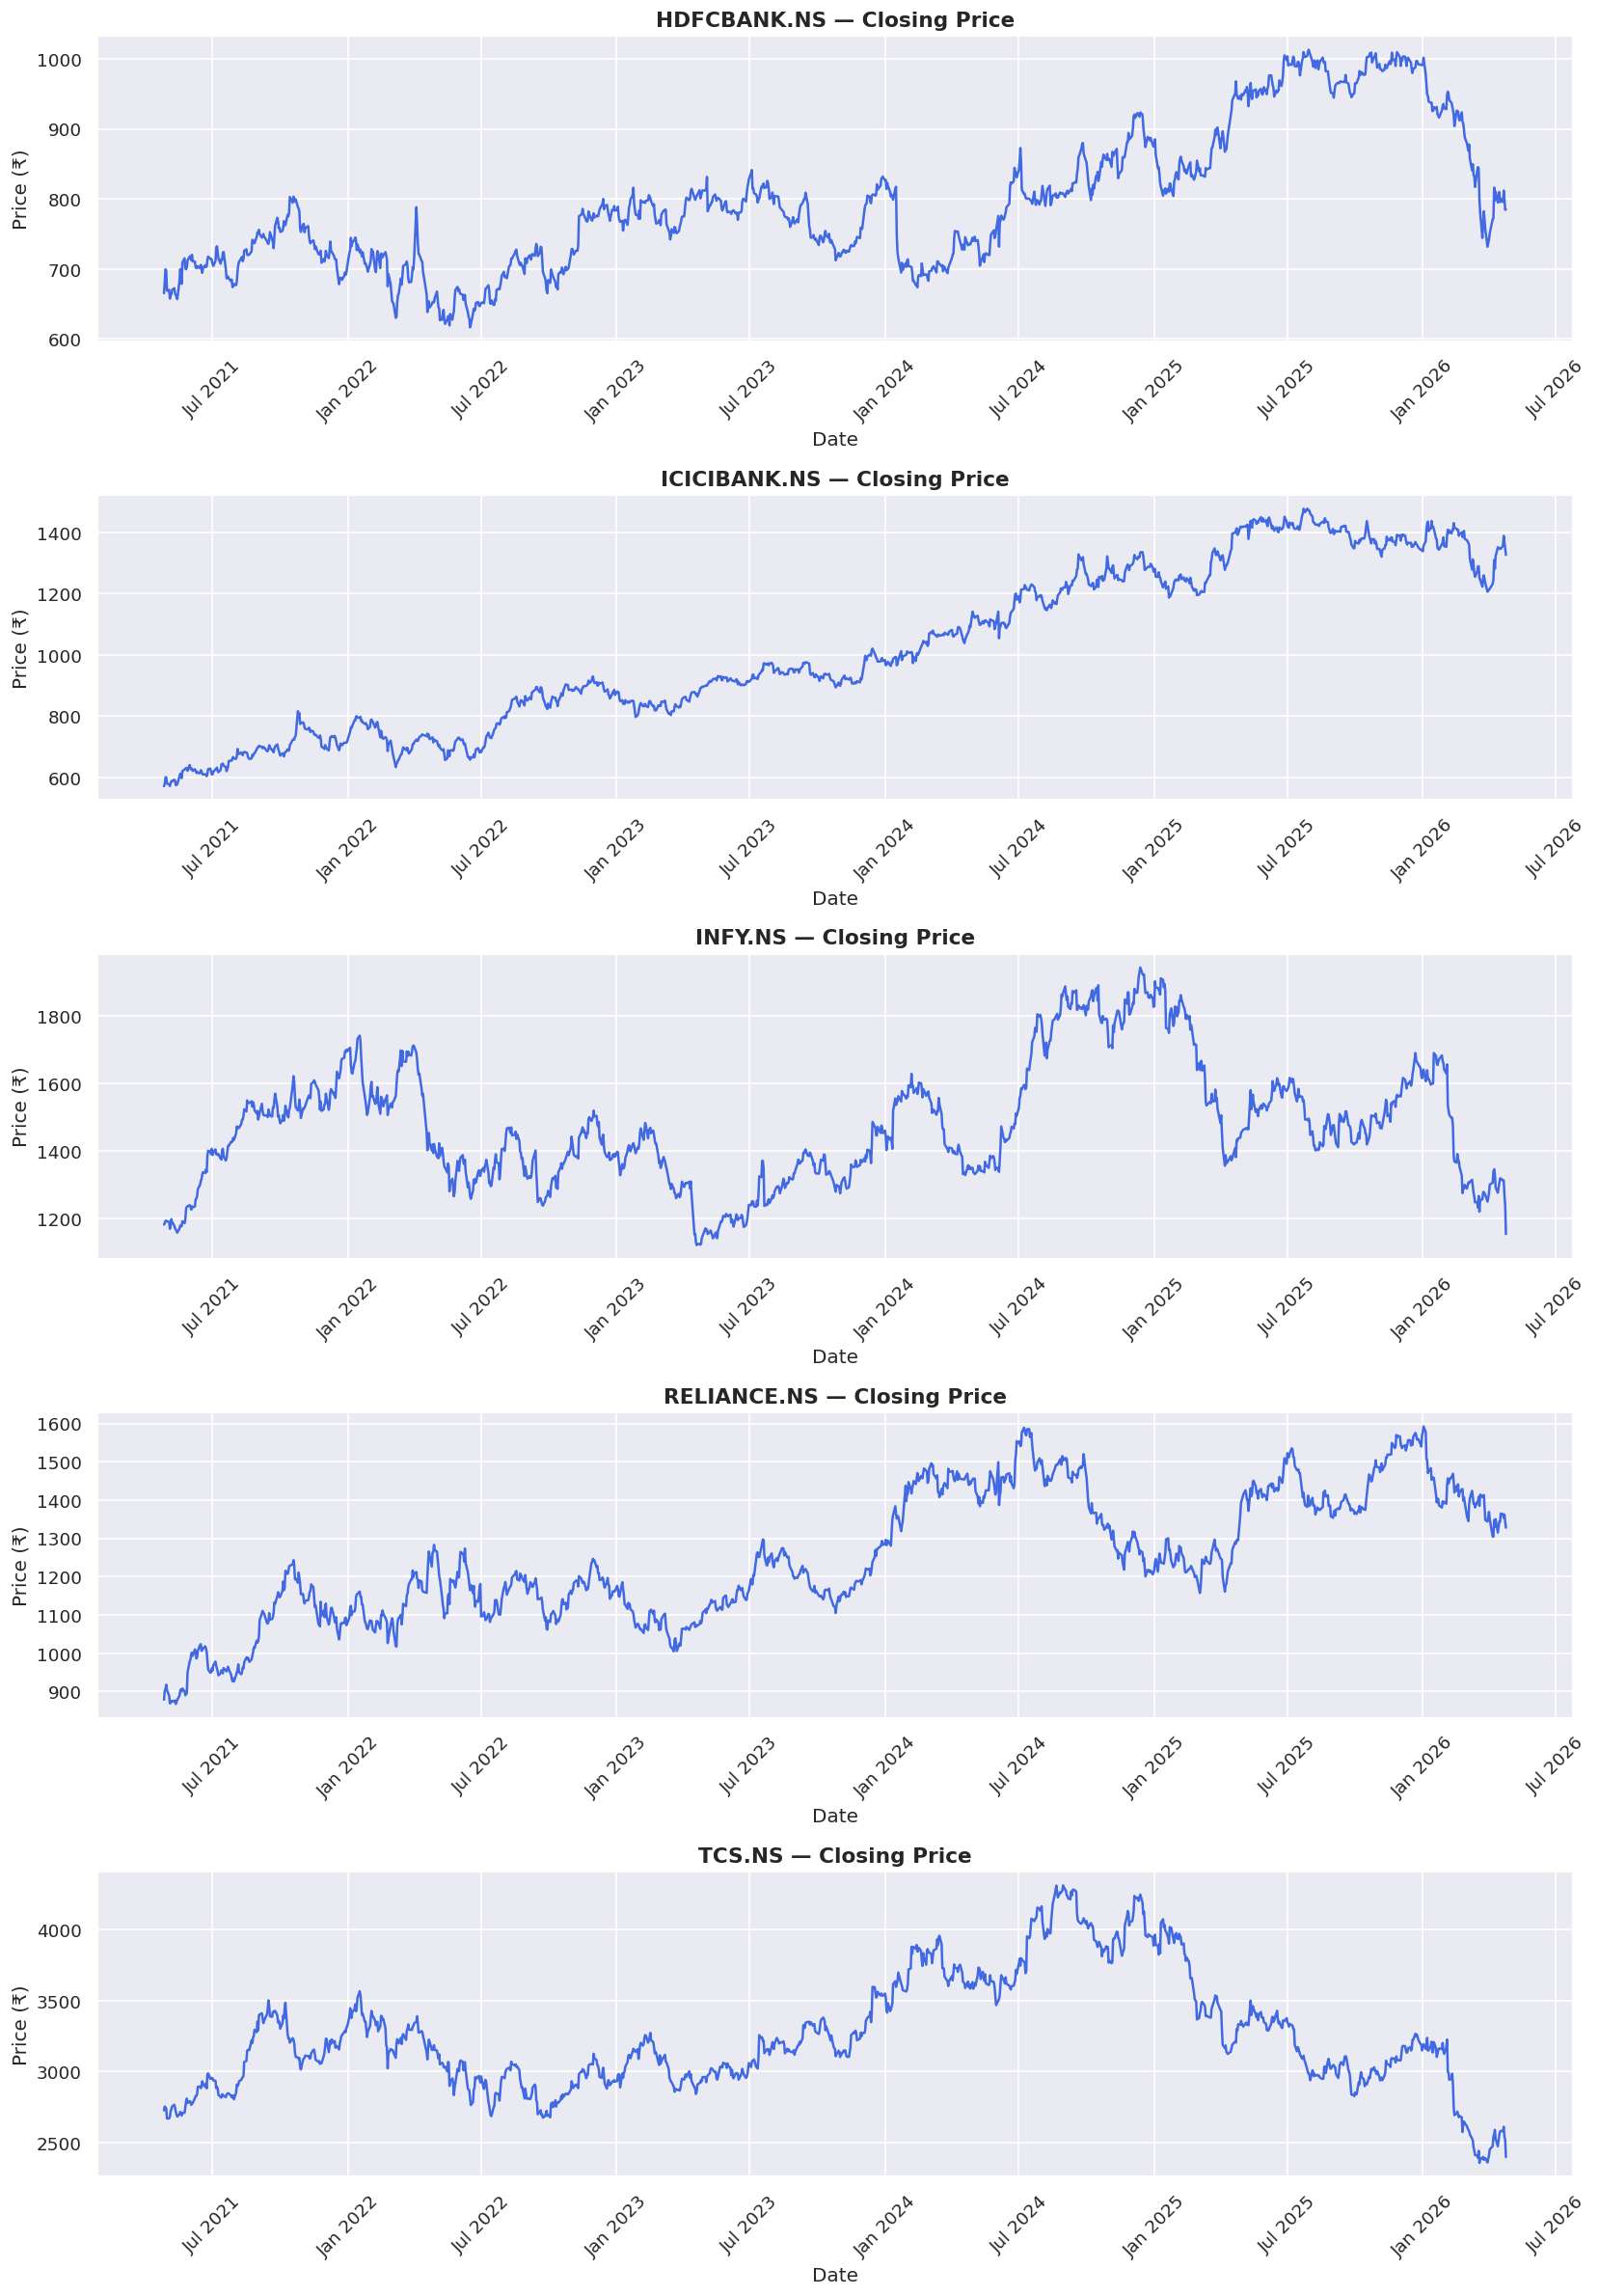

In [15]:
symbols = df["Symbol"].unique()
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 4 * len(symbols)), sharex=False)

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.plot(data["Date"], data["Close"], linewidth=1.5, color="royalblue")
    ax.set_title(f"{symbol} — Closing Price", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("trend_closing_price.png", bbox_inches="tight")
plt.show()

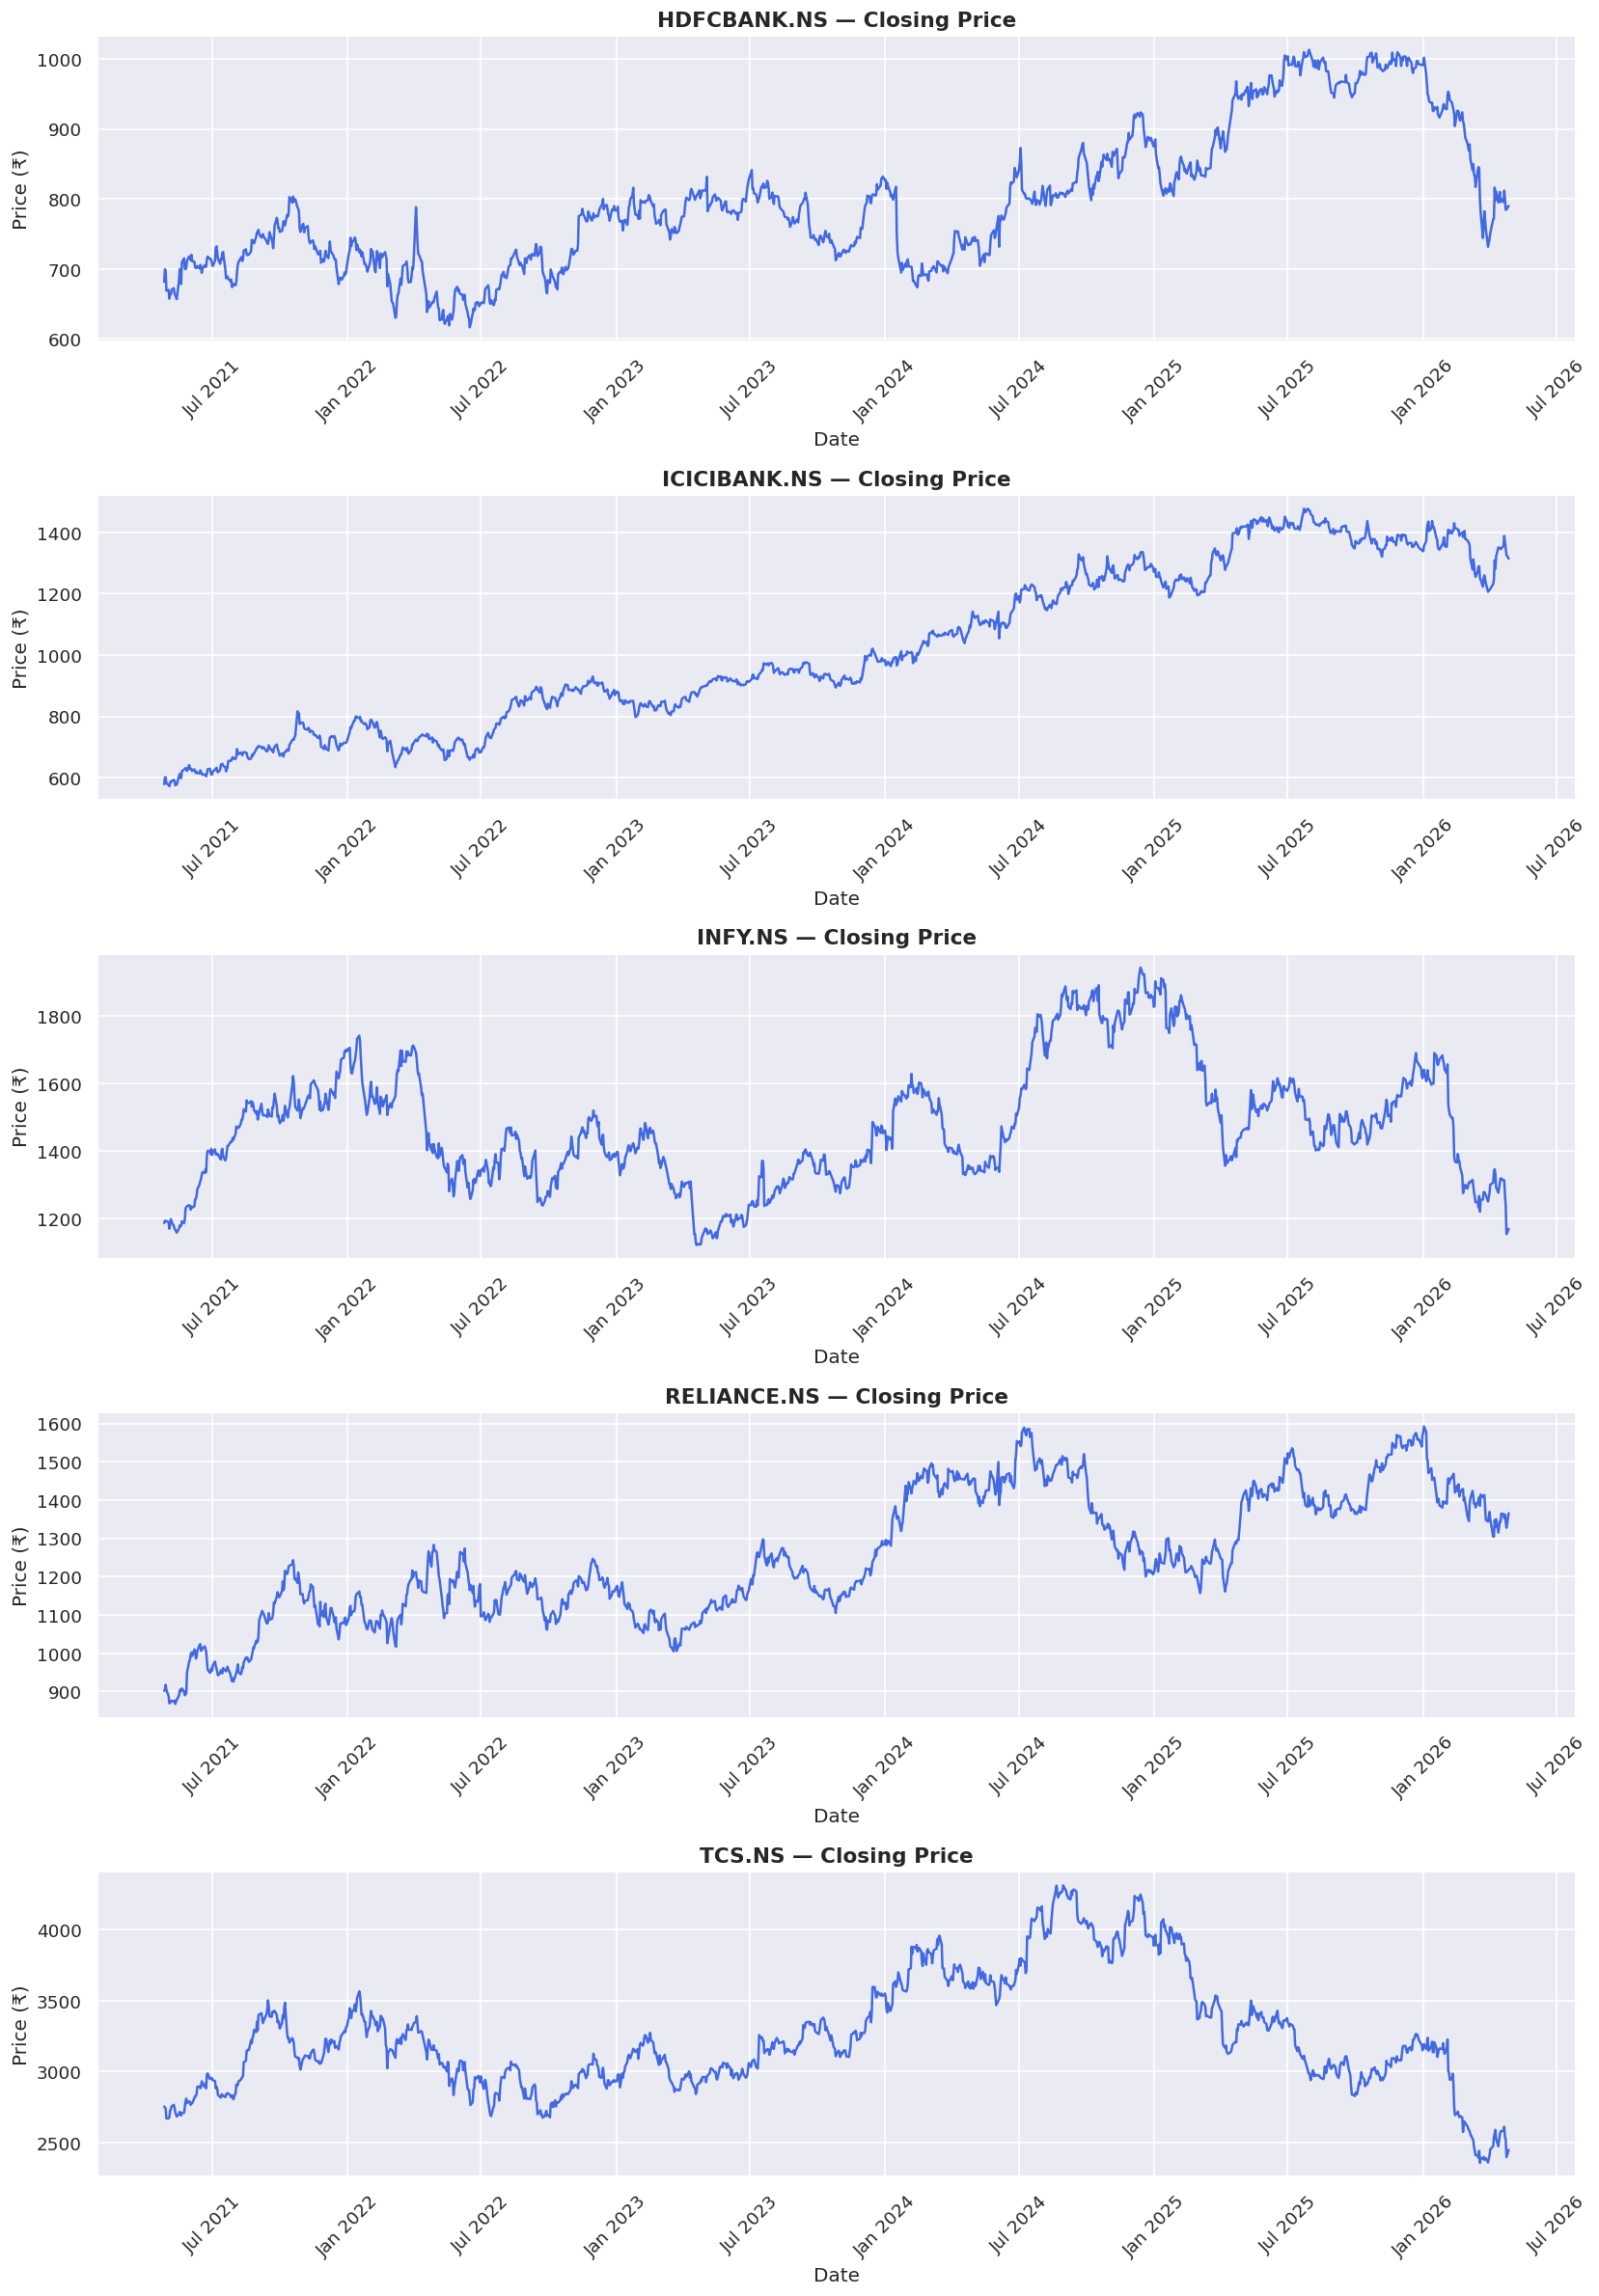

In [8]:
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 4 * len(symbols)), sharex=False)

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.bar(data["Date"], data["Volume"], color="royalblue", alpha=0.6, width=1.5)
    ax.set_title(f"{symbol} — Volume", fontsize=13, fontweight="bold")
    ax.set_ylabel("Volume")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("trend_volume.png", bbox_inches="tight")
plt.show()

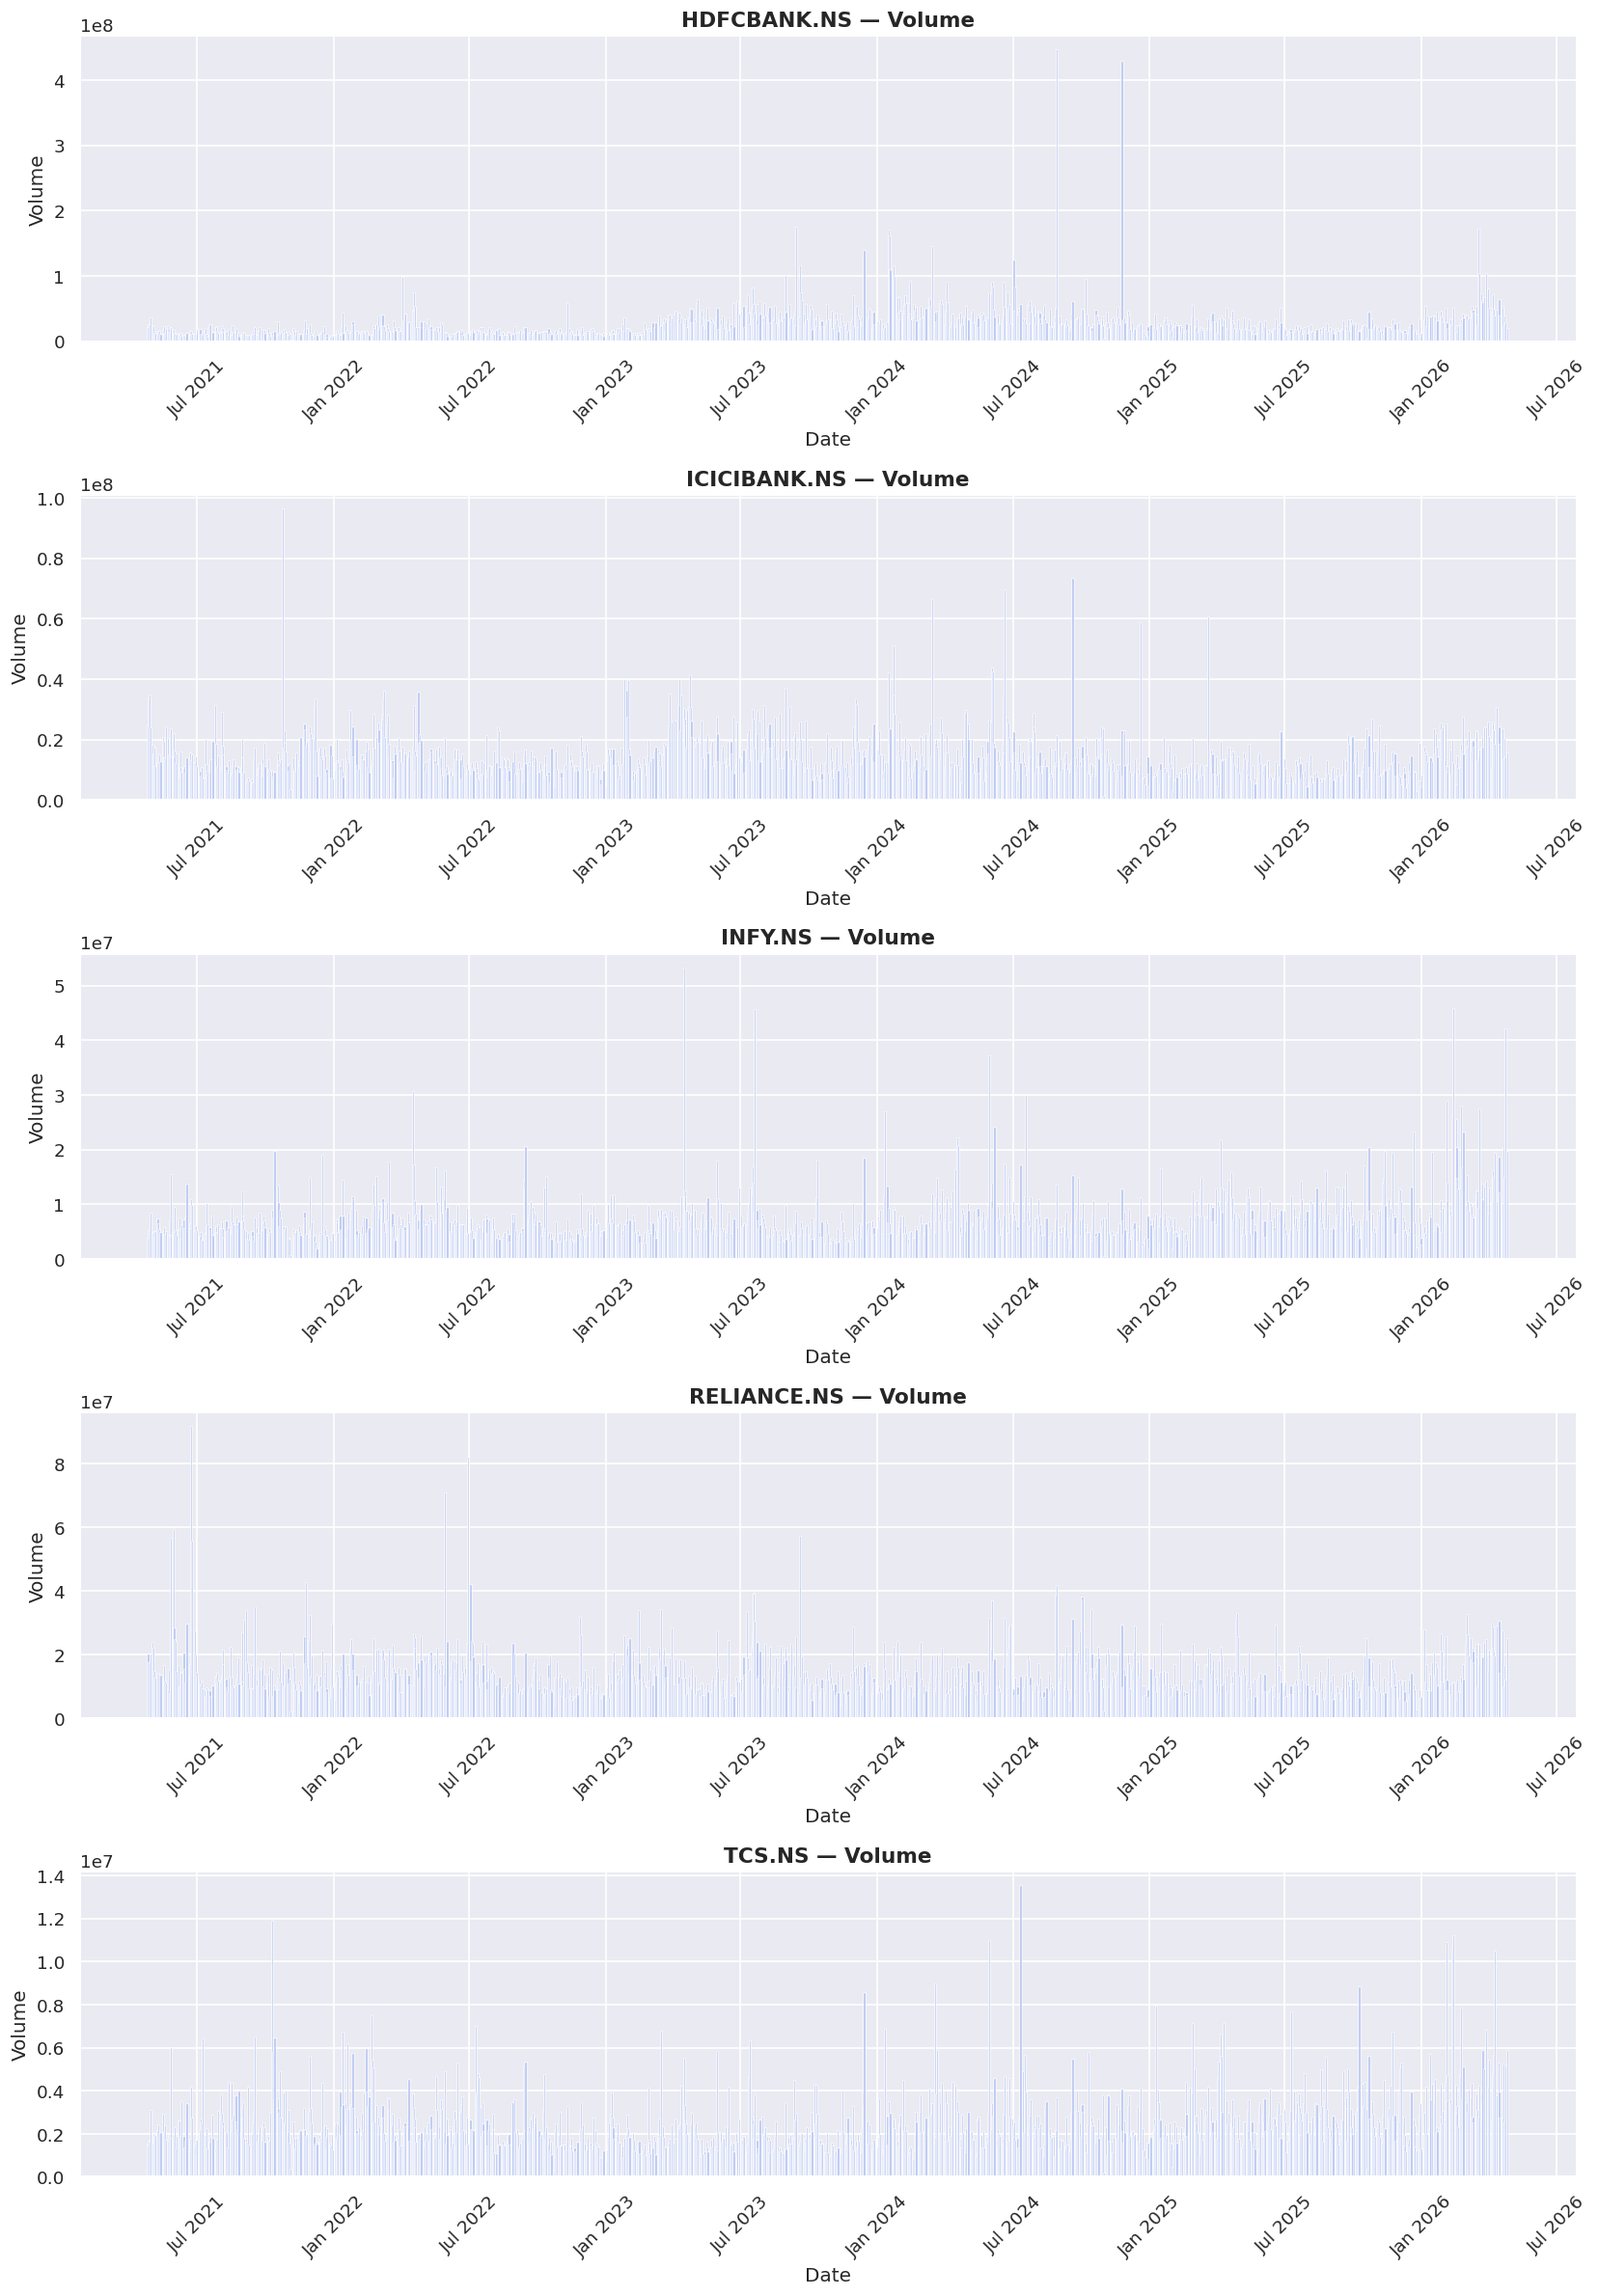

In [9]:
# Calculate indicators
for symbol in symbols:
    mask = df["Symbol"] == symbol
    df.loc[mask, "SMA_20"]  = df.loc[mask, "Close"].rolling(window=20).mean()
    df.loc[mask, "SMA_50"]  = df.loc[mask, "Close"].rolling(window=50).mean()
    df.loc[mask, "EMA_20"]  = df.loc[mask, "Close"].ewm(span=20, adjust=False).mean()
    df.loc[mask, "EMA_50"]  = df.loc[mask, "Close"].ewm(span=50, adjust=False).mean()

# Plot
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 5 * len(symbols)))

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.plot(data["Date"], data["Close"],  label="Close",  linewidth=1,   color="grey",      alpha=0.7)
    ax.plot(data["Date"], data["SMA_20"], label="SMA 20", linewidth=1.5, color="royalblue")
    ax.plot(data["Date"], data["SMA_50"], label="SMA 50", linewidth=1.5, color="orange")
    ax.plot(data["Date"], data["EMA_20"], label="EMA 20", linewidth=1.5, color="green",    linestyle="--")
    ax.plot(data["Date"], data["EMA_50"], label="EMA 50", linewidth=1.5, color="red",      linestyle="--")
    ax.set_title(f"{symbol} — Moving Averages", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("moving_averages.png", bbox_inches="tight")
plt.show()

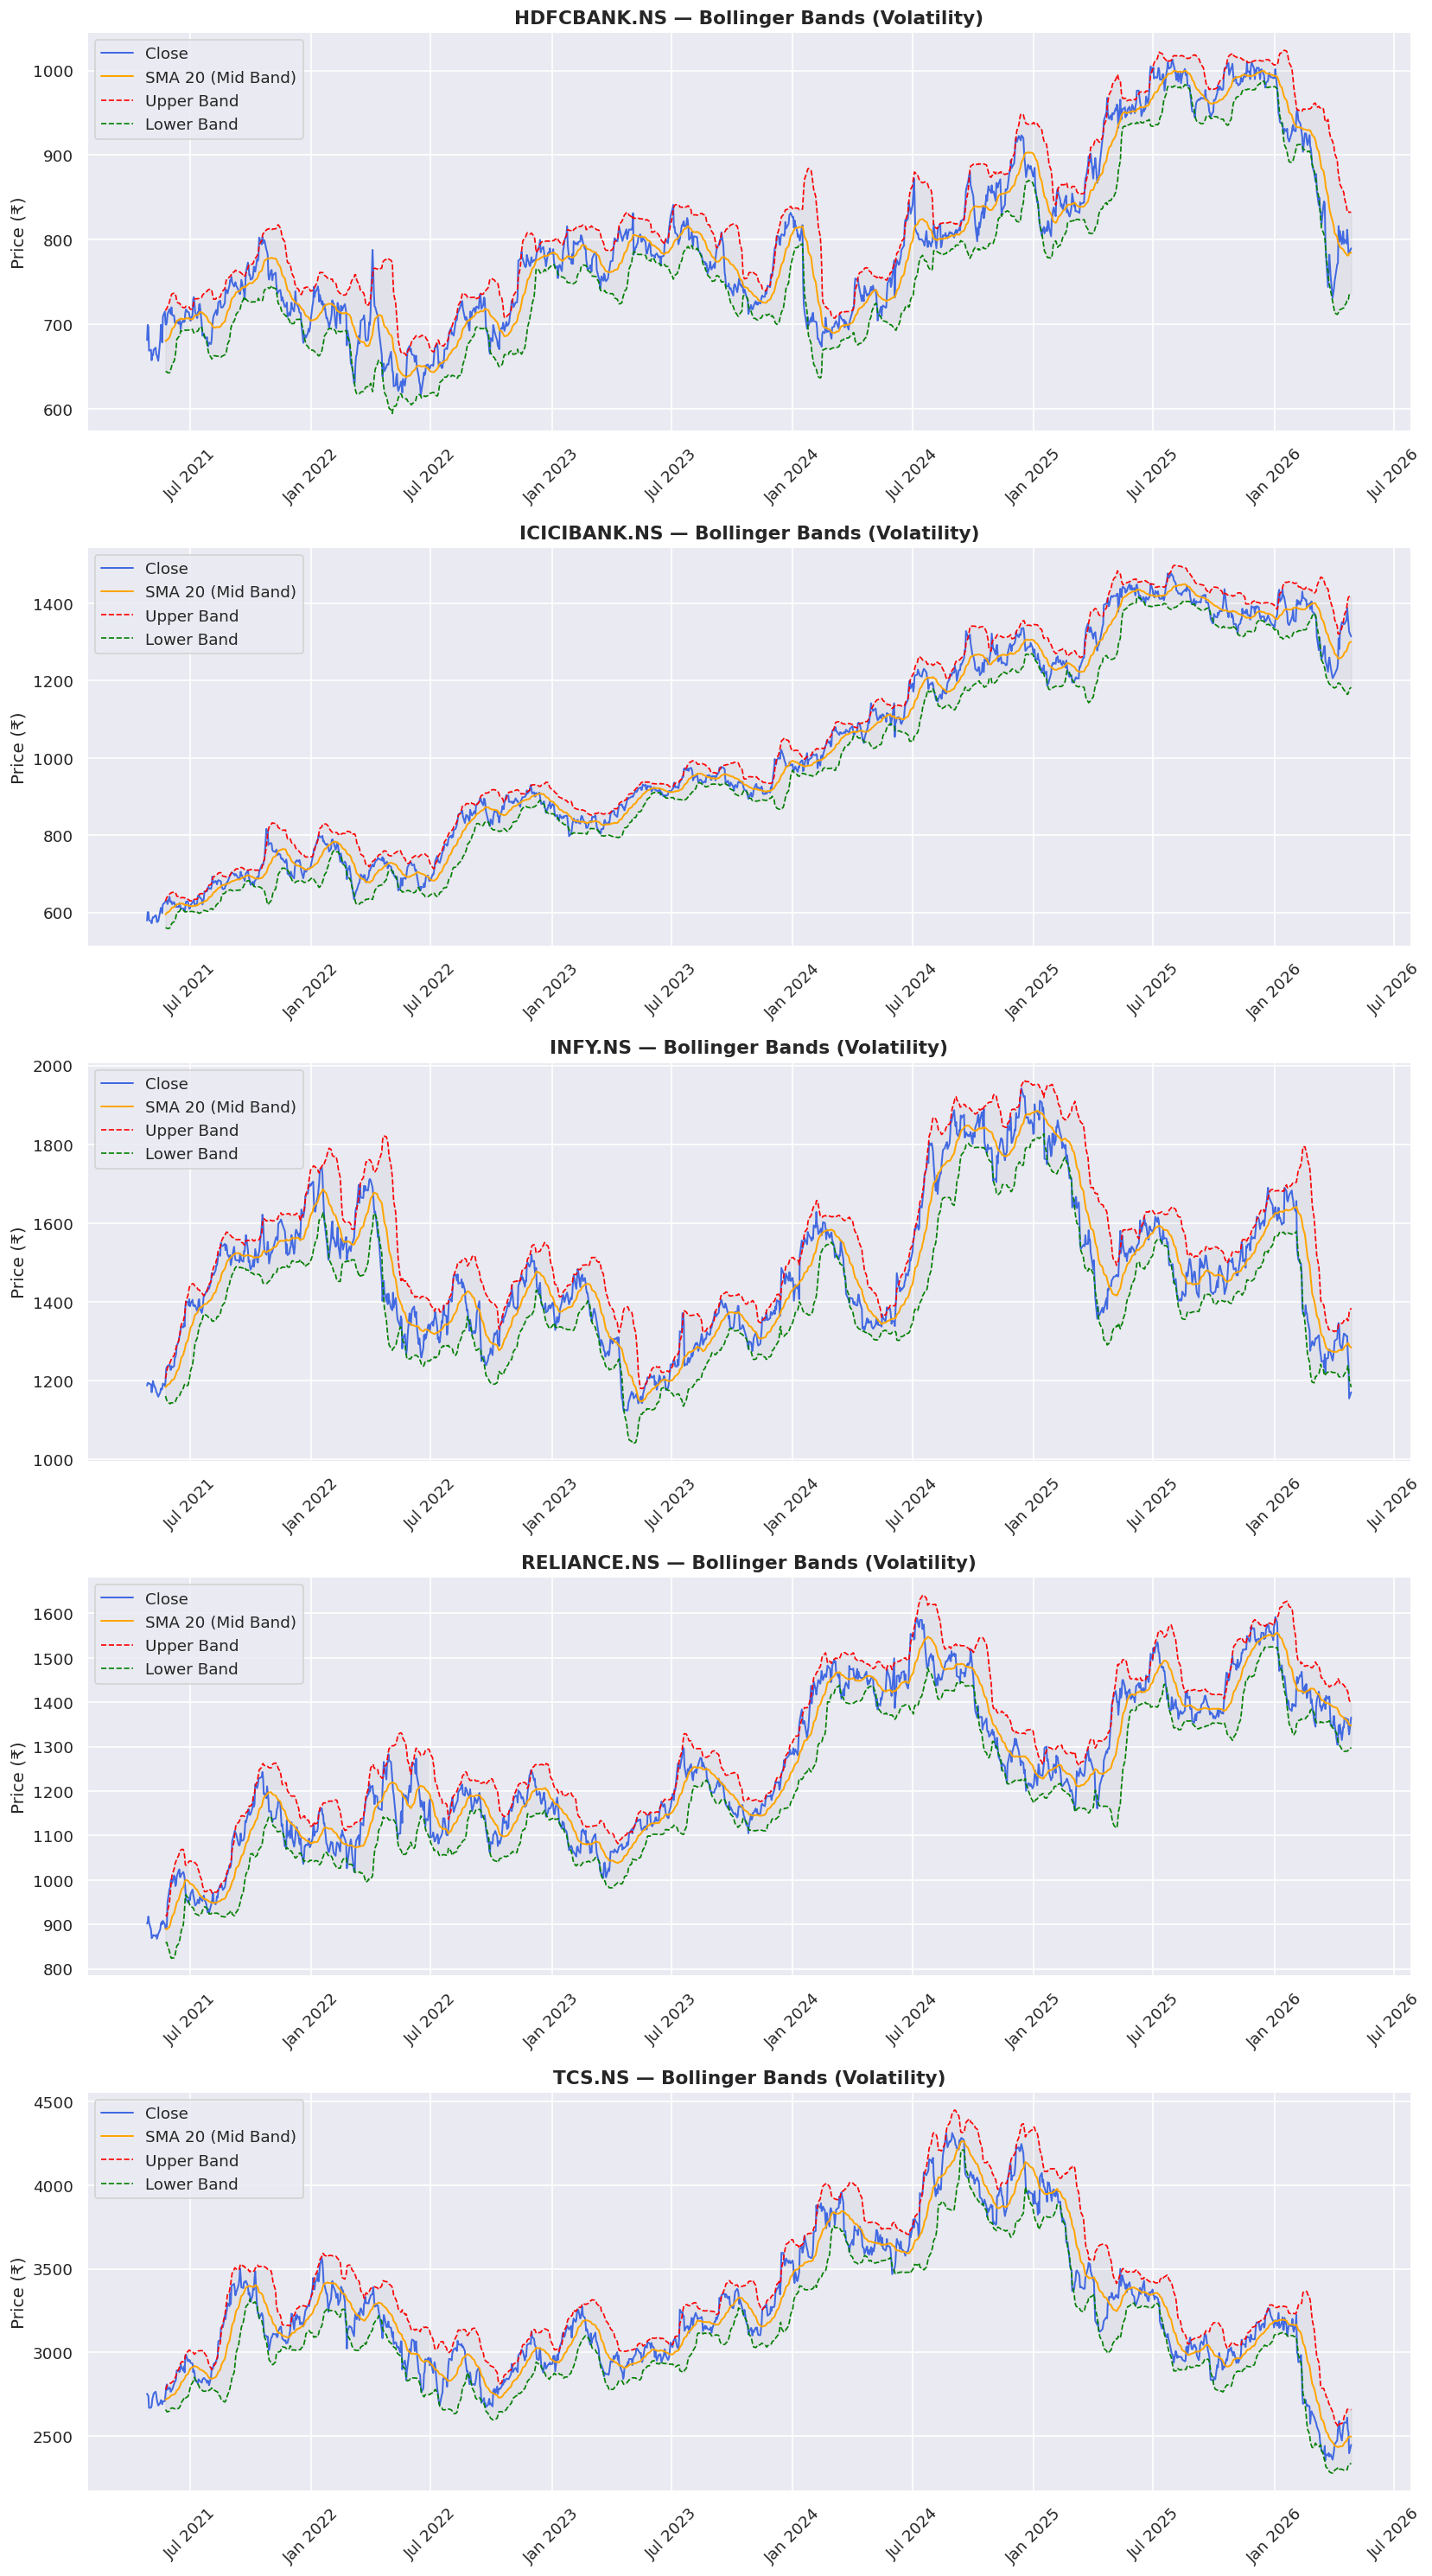

In [11]:
for symbol in symbols:
    mask = df["Symbol"] == symbol
    df.loc[mask, "Rolling_Std"] = df.loc[mask, "Close"].rolling(window=20).std()
    df.loc[mask, "BB_Upper"]    = df.loc[mask, "SMA_20"] + 2 * df.loc[mask, "Rolling_Std"]
    df.loc[mask, "BB_Lower"]    = df.loc[mask, "SMA_20"] - 2 * df.loc[mask, "Rolling_Std"]

fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 5 * len(symbols)))

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.plot(data["Date"], data["Close"],    label="Close",            color="royalblue", linewidth=1.2)
    ax.plot(data["Date"], data["SMA_20"],   label="SMA 20 (Mid Band)",color="orange",    linewidth=1.2)
    ax.plot(data["Date"], data["BB_Upper"], label="Upper Band",       color="red",       linewidth=1, linestyle="--")
    ax.plot(data["Date"], data["BB_Lower"], label="Lower Band",       color="green",     linewidth=1, linestyle="--")
    ax.fill_between(data["Date"], data["BB_Upper"], data["BB_Lower"], alpha=0.08, color="grey")
    ax.set_title(f"{symbol} — Bollinger Bands (Volatility)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("bollinger_bands.png", bbox_inches="tight")
plt.show()

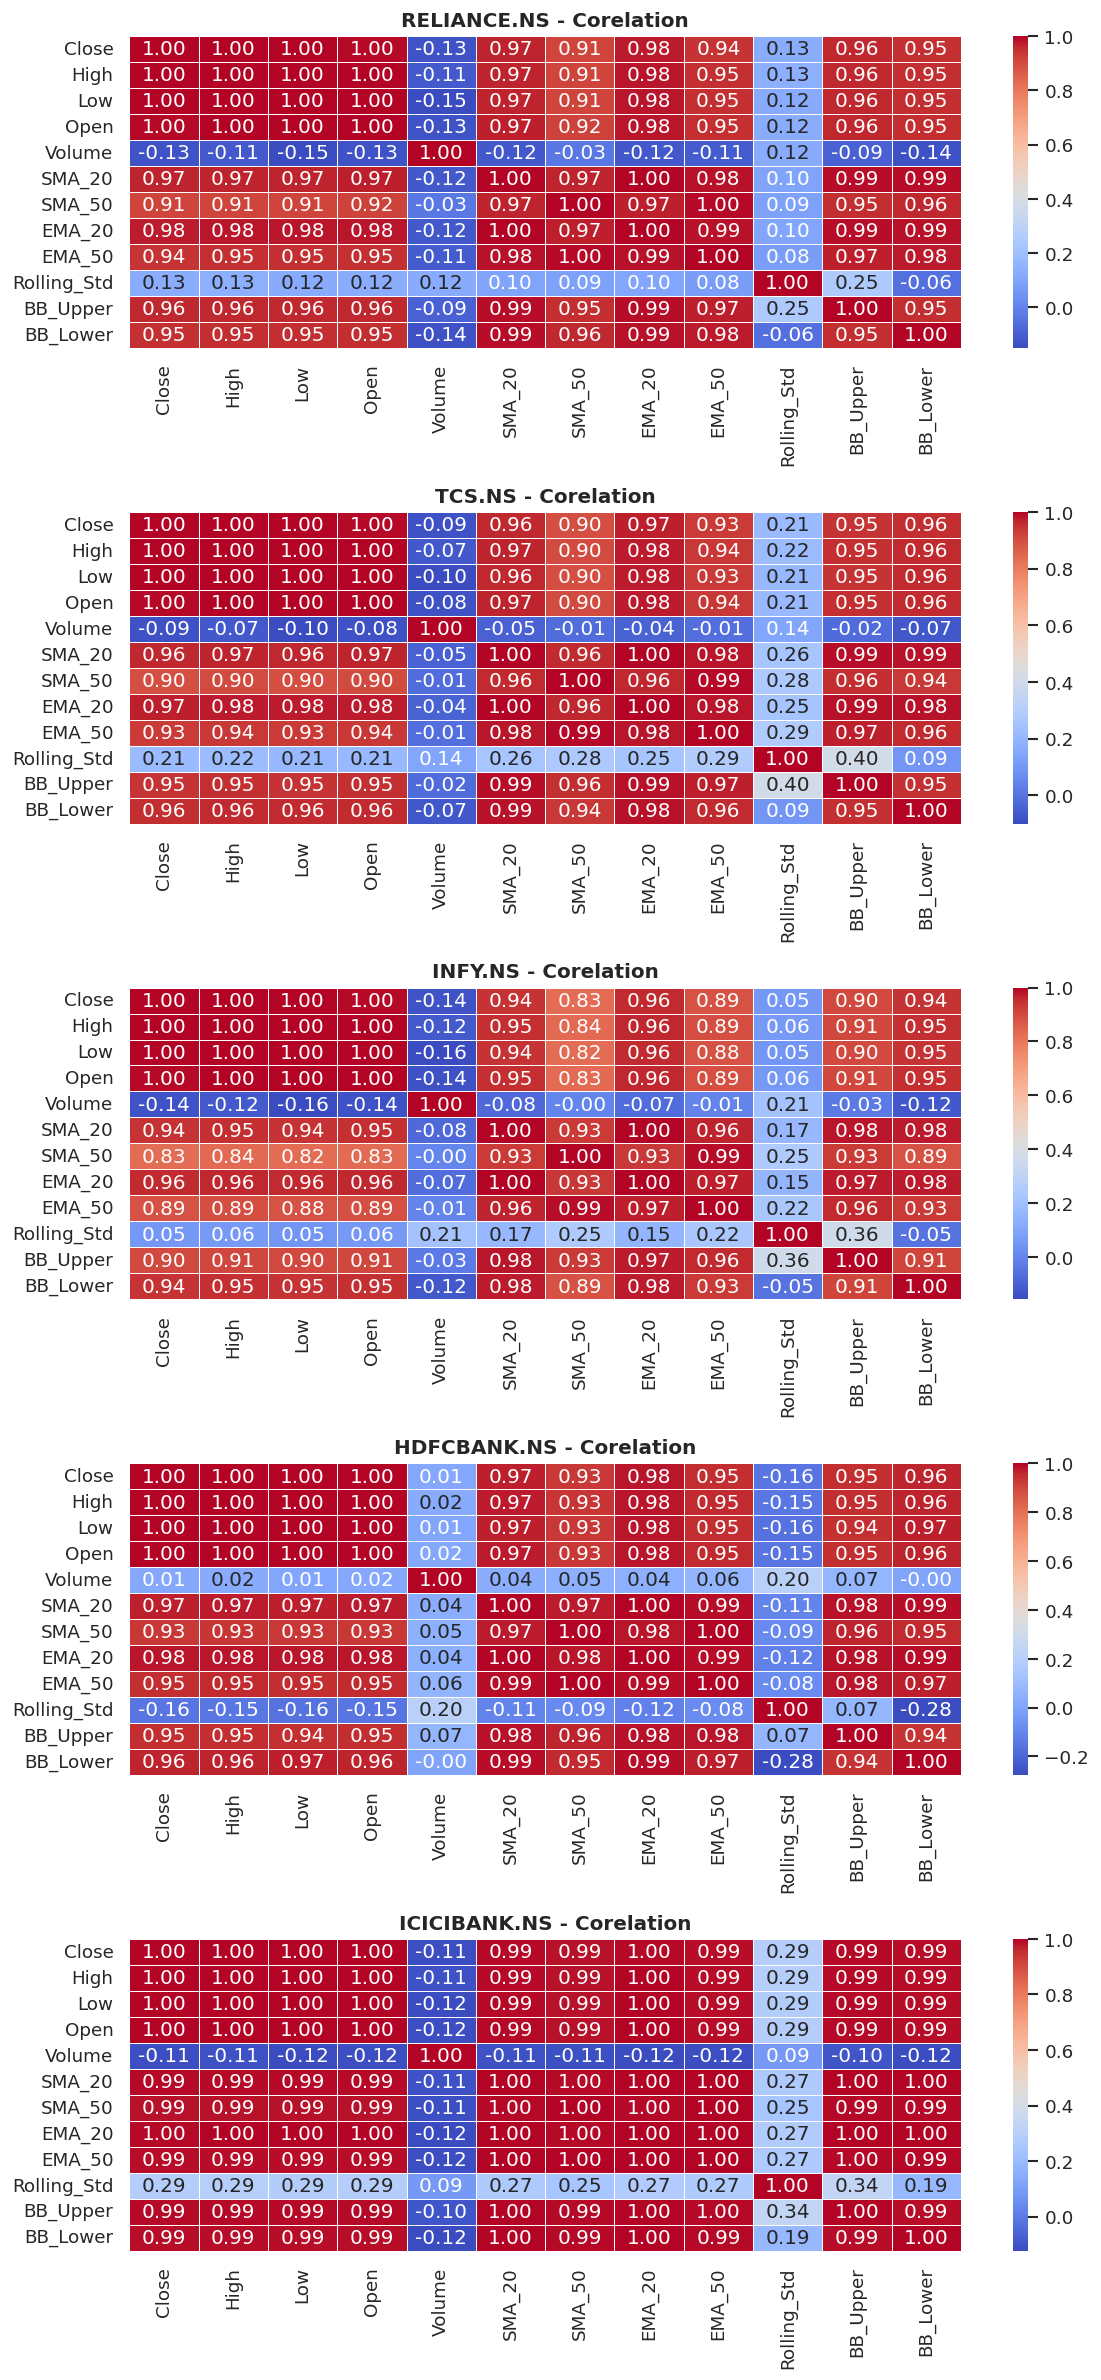

In [12]:
fig, axes = plt.subplots(len(STOCKS), 1, figsize=(10, 20))
for index, stock in enumerate(STOCKS):
    stock_df = df[df["Symbol"] == stock]
    cols = [col for col in df.columns.to_list() if col not in ["Symbol","Date"]]
    corr = stock_df[cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=axes[index])
    axes[index].set_title(stock + " - Corelation", fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [13]:
print("=" * 60)
print("📊 KEY INSIGHTS SUMMARY")
print("=" * 60)

for symbol in symbols:
    data = df[df["Symbol"] == symbol].copy()
    total_return = ((data["Close"].iloc[-1] - data["Close"].iloc[0]) / data["Close"].iloc[0]) * 100
    avg_vol      = data["Rolling_Std"].mean()
    max_price    = data["Close"].max()
    min_price    = data["Close"].min()

    print(f"\n📌 {symbol}")
    print(f"   Total Return     : {total_return:.2f}%")
    print(f"   Price Range      : ₹{min_price:.2f} → ₹{max_price:.2f}")
    print(f"   Avg Volatility   : {avg_vol:.2f}")

    # Trend signal based on last SMA crossover
    last = data.dropna(subset=["SMA_20", "SMA_50"]).iloc[-1]
    signal = "🟢 Bullish (SMA20 > SMA50)" if last["SMA_20"] > last["SMA_50"] else "🔴 Bearish (SMA20 < SMA50)"
    print(f"   Current Signal   : {signal}")

print("\n" + "=" * 60)

📊 KEY INSIGHTS SUMMARY

📌 HDFCBANK.NS
   Total Return     : 15.92%
   Price Range      : ₹616.52 → ₹1012.90
   Avg Volatility   : 16.72
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 ICICIBANK.NS
   Total Return     : 126.92%
   Price Range      : ₹572.14 → ₹1477.20
   Avg Volatility   : 21.04
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 INFY.NS
   Total Return     : -1.42%
   Price Range      : ₹1122.01 → ₹1942.22
   Avg Volatility   : 39.54
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 RELIANCE.NS
   Total Return     : 51.47%
   Price Range      : ₹867.48 → ₹1592.30
   Avg Volatility   : 29.54
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 TCS.NS
   Total Return     : -11.10%
   Price Range      : ₹2356.00 → ₹4311.59
   Avg Volatility   : 74.85
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)



In [17]:
save_to_csv(df,"processed_data.csv")


✅ CSV saved successfully with 6185 total rows
Symbol
HDFCBANK.NS     1237
ICICIBANK.NS    1237
INFY.NS         1237
RELIANCE.NS     1237
TCS.NS          1237
Name: rows, dtype: int64
